In [ ]:
!pip install ultralytics -q
!pip install roboflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.0/184.0 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 134.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib as plt
import os
import glob
import time
from PIL import Image

import torch
import torchvision
from ultralytics import RTDETR

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA is available: {torch.cuda.is_available()}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch version: 2.10.0+cu128
CUDA is available: True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_PATH = '/content/drive/MyDrive/100-days-of-ml/capstone-autonomous-perception'
os.makedirs(SAVE_PATH, exist_ok=True)

print(f"Save path: {SAVE_PATH}")

Mounted at /content/drive
Save path: /content/drive/MyDrive/100-days-of-ml/capstone-autonomous-perception


In [ ]:
"""

Why RT-DETR over YOLO?

Higher accuracy than YOLOv8s
Transformer architecture
Faster inference than YOLOv8s

"""

'\n\nWhy RT-DETR over YOLO?\n\nHigher accuracy than YOLOv8s\nTransformer architecture\nFaster inference than YOLOv8s\n\n'

In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="lmPdJ3oLeIMWnkB3t3vq")
print(rf.workspace())

loading Roboflow workspace...
{
  "name": "Aryans Workspace",
  "url": "aryans-workspace-pd48k",
  "projects": [
    "aryans-workspace-pd48k/bdd100k-nit3m"
  ]
}


In [ ]:
import zipfile

zip_path = f'{SAVE_PATH}/archive.zip'
LOCAL_ROOT = '/content/bdd100k_local'

# Verify zip integrity first
assert os.path.exists(zip_path), f"archive.zip not found at {zip_path}"
size_gb = os.path.getsize(zip_path) / (1024 ** 3)
print(f"archive.zip size: {size_gb:.2f} GB")

# Extract to local Colab disk (fast SSD, no FUSE throttling)
print("Extracting to local storage...")
with zipfile.ZipFile(zip_path, 'r') as z:
    file_list = z.namelist()
    print(f"Total entries in zip: {len(file_list):,}")

    # Quick sanity check: how many train images are in the zip?
    train_in_zip = [f for f in file_list if 'images/100k/train/' in f and f.endswith('.jpg')]
    val_in_zip   = [f for f in file_list if 'images/100k/val/'   in f and f.endswith('.jpg')]
    print(f"Train images in zip: {len(train_in_zip):,}")
    print(f"Val images in zip:   {len(val_in_zip):,}")

    assert len(train_in_zip) >= 60000, (
        f"Only {len(train_in_zip)} train images in zip — "
        "the download was likely interrupted. Re-download from Kaggle."
    )

    z.extractall(LOCAL_ROOT)

print("Extraction complete!")

archive.zip size: 7.61 GB
Extracting to local storage...
Total entries in zip: 136,002
Train images in zip: 70,000
Val images in zip:   10,000
Extraction complete!


In [ ]:
import subprocess

# Show the actual directory tree so we never guess at nesting
result = subprocess.run(
    ['find', LOCAL_ROOT, '-type', 'd', '-maxdepth', '6'],
    capture_output=True, text=True
)
print(result.stdout)


In [ ]:
import zipfile

zip_path = f'{SAVE_PATH}/archive.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    file_list = z.namelist()

    # Find all train image paths in the zip
    train_paths = [f for f in file_list if 'images/100k/train/' in f and f.endswith('.jpg')]

    print(f"Total entries in zip: {len(file_list):,}")
    print(f"Train .jpg entries:   {len(train_paths):,}")

    # Show the first 10 paths to see the exact nesting
    print("\nFirst 10 train image paths inside zip:")
    for p in sorted(train_paths)[:10]:
        print(f"  {p}")

    # Check if there are multiple different prefixes
    # (i.e., images split across different subdirectories)
    prefixes = set()
    for p in train_paths:
        prefix = p.split('images/100k/train/')[0]
        prefixes.add(prefix)

    print(f"\nUnique path prefixes: {len(prefixes)}")
    for prefix in sorted(prefixes):
        count = sum(1 for p in train_paths if p.startswith(prefix))
        print(f"  '{prefix}' -> {count:,} images")

In [ ]:
import shutil

# Check available disk space
total, used, free = shutil.disk_usage('/content')
print(f"Colab disk: {total/1e9:.1f} GB total, {used/1e9:.1f} GB used, {free/1e9:.1f} GB free")

# Check how much space the partial extraction took
!du -sh /content/bdd100k_local/

# Also check if extraction threw any errors we missed -
# try extracting just 5 files as a test
import zipfile
zip_path = f'{SAVE_PATH}/archive.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    train_paths = [f for f in z.namelist() if 'images/100k/train/' in f and f.endswith('.jpg')]

    # Try extracting a file that DIDN'T make it (pick one past index 1156)
    test_file = sorted(train_paths)[2000]
    print(f"\nTest extracting: {test_file}")
    z.extract(test_file, '/content/bdd100k_local')

    extracted = f'/content/bdd100k_local/{test_file}'
    if os.path.exists(extracted):
        print(f"SUCCESS - file exists, size: {os.path.getsize(extracted):,} bytes")
    else:
        print("FAILED - file not written to disk")

In [ ]:
# Check subdirectories inside train/
train_dir = '/content/bdd100k_local/bdd100k/bdd100k/images/100k/train'
subdirs = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
print(f"Subdirectories in train/: {subdirs}")

# Count with recursive glob
all_train = glob.glob(f'{train_dir}/**/*.jpg', recursive=True)
flat_train = glob.glob(f'{train_dir}/*.jpg')
print(f"\nFlat glob (*.jpg):        {len(flat_train):,}")
print(f"Recursive glob (**/*.jpg): {len(all_train):,}")

In [ ]:
# Dynamically find the real train/val image directories
for root, dirs, files in os.walk(LOCAL_ROOT):
    if root.endswith('images/100k/train'):
        IMG_TRAIN = root
    elif root.endswith('images/100k/val'):
        IMG_VAL = root
    elif root.endswith('bdd100k/labels') and any(f.endswith('.json') for f in files):
        JSON_LABELS_DIR = root

print(f"IMG_TRAIN      : {IMG_TRAIN}")
print(f"IMG_VAL        : {IMG_VAL}")
print(f"JSON_LABELS_DIR: {JSON_LABELS_DIR}")

# CRITICAL: use recursive glob — BDD100K has subdirectories inside train/
train_images = sorted(glob.glob(f'{IMG_TRAIN}/**/*.jpg', recursive=True))
val_images   = sorted(glob.glob(f'{IMG_VAL}/**/*.jpg', recursive=True))

print(f"\nTrain images found: {len(train_images):,}")
print(f"Val images found:   {len(val_images):,}")

assert len(train_images) >= 60000, (
    f"Expected ~70k train images but found {len(train_images):,}. "
    "Check extraction or re-download."
)

In [ ]:
# Flatten: move all images from subdirectories into train/ and val/ directly
import shutil

for split_dir in [IMG_TRAIN, IMG_VAL]:
    for root, dirs, files in os.walk(split_dir):
        if root == split_dir:
            continue
        for fname in files:
            if fname.endswith('.jpg'):
                src = os.path.join(root, fname)
                dst = os.path.join(split_dir, fname)
                if not os.path.exists(dst):
                    shutil.move(src, dst)

    # Remove now-empty subdirectories
    for d in os.listdir(split_dir):
        full = os.path.join(split_dir, d)
        if os.path.isdir(full):
            shutil.rmtree(full)

# Verify flat structure
train_images = sorted(glob.glob(f'{IMG_TRAIN}/*.jpg'))
val_images   = sorted(glob.glob(f'{IMG_VAL}/*.jpg'))
print(f"Train images (flattened): {len(train_images):,}")
print(f"Val images (flattened):   {len(val_images):,}")

Converting BDD100K JSON Labels to YOLO Format

In [ ]:
import json
from tqdm import tqdm

CLASS_NAMES = [
    'car', 'truck', 'bus', 'person', 'rider',
    'bicycle', 'motorcycle', 'traffic light', 'traffic sign', 'train'
]
CLASS_MAP = {name: i for i, name in enumerate(CLASS_NAMES)}

def convert_bdd_to_yolo(json_path, output_dir, img_width=1280, img_height=720):
    """Convert a BDD100K JSON annotation file to per-image YOLO .txt labels."""
    with open(json_path, 'r') as f:
        data = json.load(f)

    skipped = 0
    for item in tqdm(data, desc=os.path.basename(json_path)):
        img_name = item['name'].replace('.jpg', '.txt')
        labels = item.get('labels', [])

        yolo_lines = []
        for label in labels:
            category = label.get('category', '')
            if category not in CLASS_MAP:
                skipped += 1
                continue

            box2d = label.get('box2d', None)
            if box2d is None:
                continue

            x1, y1 = box2d['x1'], box2d['y1']
            x2, y2 = box2d['x2'], box2d['y2']

            x_center = ((x1 + x2) / 2) / img_width
            y_center = ((y1 + y2) / 2) / img_height
            width    = (x2 - x1) / img_width
            height   = (y2 - y1) / img_height

            class_id = CLASS_MAP[category]
            yolo_lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

        with open(os.path.join(output_dir, img_name), 'w') as f:
            f.write('\n'.join(yolo_lines))

    print(f"  Wrote {len(data):,} label files, skipped {skipped:,} non-target annotations")

# images/100k/train  ->  labels/100k/train
LABEL_TRAIN = IMG_TRAIN.replace('/images/', '/labels/')
LABEL_VAL   = IMG_VAL.replace('/images/', '/labels/')
os.makedirs(LABEL_TRAIN, exist_ok=True)
os.makedirs(LABEL_VAL, exist_ok=True)

print(f"Label output dirs:")
print(f"  Train: {LABEL_TRAIN}")
print(f"  Val:   {LABEL_VAL}")

# Find the JSON label files
train_json = os.path.join(JSON_LABELS_DIR, 'bdd100k_labels_images_train.json')
val_json   = os.path.join(JSON_LABELS_DIR, 'bdd100k_labels_images_val.json')
assert os.path.exists(train_json), f"Train JSON not found: {train_json}"
assert os.path.exists(val_json),   f"Val JSON not found: {val_json}"

print("\nConverting train labels...")
convert_bdd_to_yolo(train_json, LABEL_TRAIN)

print("\nConverting val labels...")
convert_bdd_to_yolo(val_json, LABEL_VAL)

print("\nDone!")

In [ ]:
import glob

# Using the local dataset paths where we safely extracted the full dataset
LOCAL_TRAIN_DIR = '/content/bdd100k_local/bdd100k/bdd100k/images/100k/train'
LOCAL_VAL_DIR = '/content/bdd100k_local/bdd100k/bdd100k/images/100k/val'

final_train_images = glob.glob(f'{LOCAL_TRAIN_DIR}/*.jpg')
final_val_images = glob.glob(f'{LOCAL_VAL_DIR}/*.jpg')

print(f"Total training images loaded: {len(final_train_images):,}")
print(f"Total validation (test) images loaded: {len(final_val_images):,}")

In [ ]:
# Re-define train_images and val_images using the local, flattened image directories
import glob

# Ensure LOCAL_TRAIN_DIR and LOCAL_VAL_DIR are defined
# (These should be defined in cell u2ptQgCKrUn5)
LOCAL_TRAIN_DIR = '/content/bdd100k_local/bdd100k/bdd100k/images/100k/train'
LOCAL_VAL_DIR = '/content/bdd100k_local/bdd100k/bdd100k/images/100k/val'

train_images = sorted(glob.glob(f'{LOCAL_TRAIN_DIR}/*.jpg'))
val_images   = sorted(glob.glob(f'{LOCAL_VAL_DIR}/*.jpg'))

print(f"Train images defined: {len(train_images):,}")
print(f"Validation images defined: {len(val_images):,}")

Train images defined: 1,156
Validation images defined: 10,000


In [ ]:
def visualize_sample(image_path, label_path, class_names):
  img = Image.open(image_path)
  img_w, img_h = img.size

  boxes = []
  if os.path.exists(label_path):
    with open(label_path, 'r') as f:
      for line in f:
        parts = line.strip().split()
        if len(parts) >= 5:
          cls_id = int(parts[0])
          x_center, y_center, w, h = map(float, parts[1:5])
          x1 = (x_center - w/2) * img_w
          x2 = (x_center + w/2) * img_w
          y1 = (y_center - h/2) * img_h
          y2 = (y_center + h/2) * img_h
          boxes.append([cls_id, x1, y1, x2, y2])

  fig, ax = plt.subplots(figsize=(12, 8))
  ax.imshow(img)

  colors = plt.cm.tab10(np.linspace(0, 1, len(class_names)))
  for cls_id, x1, y1, x2, y2 in boxes:
    color = colors[cls_id % len(colors)]
    rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor=color, linewidth=2)
    ax.add_patch(rect)
    label = class_names[cls_id] if cls_id < len(class_names) else f"Class_{cls_id}"
    ax.text(x1, y1-5, label, color='white', fontsize=10, bbox=dict(facecolor=color, alpha=0.5, boxstyle='round'))

  ax.set_title(f"Sample: {os.path.basename(image_path)}  ({len(boxes)} objects)")
  ax.axis('off')
  plt.tight_layout()
  plt.show()

In [ ]:
import matplotlib.pyplot as plt

#Visualizing some random samples
class_names = CLASS_NAMES
print(f"Classes: {class_names}\n")

sample_indices = np.random.choice(len(train_images), 4, replace=False)

for idx in sample_indices:
  img_path = train_images[idx]
  label_path = img_path.replace('/images/', '/labels/').replace('.jpg', '.txt')
  visualize_sample(img_path, label_path, class_names)


In [ ]:
from collections import Counter

class_counts = Counter()

for img_path in train_images:
  label_path = img_path.replace('/images', '/labels/').replace('.jpg', '.txt')
  if os.path.exists(label_path):
    with open(label_path, 'r') as f:
      for line in f:
        parts = line.strip().split()
        if parts:
          class_counts[int(parts[0])] += 1

fig, ax = plt.subplots(figsize=(12, 5))
classes = [class_names[i] if i < len(class_names) else f"class_{i}"
           for i in sorted(class_counts.keys())]
counts = [class_counts[i] for i in sorted(class_counts.keys())]

bars = ax.bar(classes, counts, color='steelblue', edgecolor='black')
ax.bar(classes, counts)
ax.set_xlabel('Classes')
ax.set_ylabel('Count')
ax.set_title('Class Distribution')
plt.xticks(rotation=45, ha='right')

for bar, count in zip(bars, counts):
  ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(count),
          ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"Total objects: {sum(counts):,}")


Loading Pre-Trained RT-DETR

In [ ]:
model = RTDETR('rtdetr-l.pt')

print('Model Loaded')


In [ ]:
#Testing inference before fine-tuning
sample_img = train_images[0]
results = model.predict(sample_img, verbose=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(Image.open(sample_img))
axes[0].set_title('Original')
axes[0].axis('off')

result_img = results[0].plot()
axes[1].imshow(result_img)
axes[1].set_title('Prediction')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Fine-tuning on BDD100K

In [ ]:
FINETUNED_MODEL_PATH = f"{SAVE_PATH}/rtdetr_s_bdd100k.pt"

if os.path.exists(FINETUNED_MODEL_PATH):
  print("Found existing finr-tuned model! loading  . .  .")
  model = RTDETR(FINETUNED_MODEL_PATH)
  SKIP_TRAINING = True
else:
  print("No existing model found")
  SKIP_TRAINING = False

In [ ]:
EPOCH = 20
IMG_SIZE = 640
BATCH_SIZE = 32

In [ ]:
if not SKIP_TRAINING:
  print("Starting Fine-tuning RT-DETR-s. . . ")

  # Create data.yaml for Ultralytics training
  data_yaml_content = f"""train: {IMG_TRAIN}
val: {IMG_VAL}

nc: {len(CLASS_NAMES)}
names: {CLASS_NAMES}
"""

  data_yaml_path = f"{SAVE_PATH}/data.yaml"
  with open(data_yaml_path, 'w') as f:
      f.write(data_yaml_content)
  print(f"Created data.yaml at: {data_yaml_path}")

  results = model.train(
      data = data_yaml_path,
      epochs = EPOCH,
      imgsz=IMG_SIZE,
      batch=BATCH_SIZE,
      patience=10,
      save=True,
      name='rtdetr_s_bdd100k_training',
      project=SAVE_PATH,
      exist_ok=True,
      verbose=True,
      pretrained=True
  )

  print("Training Complete")
else:
  print("Skipping Training")

Starting Fine-tuning RT-DETR-s. . . 
Created data.yaml at: /content/drive/MyDrive/100-days-of-ml/capstone-autonomous-perception/data.yaml
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/100-days-of-ml/capstone-autonomous-perception/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


       1/20      28.9G      1.285     0.8345     0.2788        420        640: 100% ━━━━━━━━━━━━ 2188/2188 1.0it/s 36:14
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 157/157 2.4it/s 1:06
                   all      10000     184067      0.508      0.322      0.325      0.163

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


       2/20      30.5G     0.9993     0.4228     0.1136        362        640: 100% ━━━━━━━━━━━━ 2188/2188 1.1it/s 31:58
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 157/157 2.5it/s 1:04
                   all      10000     184067      0.552      0.396      0.409      0.212

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/20      30.5G     0.9545     0.4383      0.121        982        640: 0% ──────────── 0/2188  0.6s

...

      13/20      30.5G      1.051     0.4195     0.1333        292        640: 100% ━━━━━━━━━━━━ 2188/2188 1.3it/s 27:04
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 157/157 2.5it/s 1:04
                   all      10000     184067      0.672      0.436      0.443      0.207

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      14/20      30.5G     0.9841     0.4148     0.1097        588        640: 0% ──────────── 0/2188  0.5s

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


      14/20      30.5G     0.9331     0.4383     0.1081        248        640: 100% ━━━━━━━━━━━━ 2188/2188 1.3it/s 27:03
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 157/157 2.5it/s 1:04
                   all      10000     184067      0.677      0.447      0.457      0.221

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      15/20      30.5G     0.9206     0.4158      0.115        557        640: 0% ──────────── 0/2188  0.5s

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


      15/20      30.5G      1.047     0.4213     0.1282        535        640: 28% ━━━───────── 612/2188 1.6it/s 7:35<16:49

In [ ]:
SAVE_PATH = '/content/drive/MyDrive/100-days-of-ml/capstone-autonomous-perception'

!ls -la {SAVE_PATH}/rtdetr_s_bdd100k_training/weights/

total 386037
-rw------- 1 root root 197649625 Apr 25 04:12 best.pt
-rw------- 1 root root 197651417 Apr 25 13:16 last.pt


In [ ]:
import json
import os
from tqdm import tqdm

SAVE_PATH = '/content/drive/MyDrive/100-days-of-ml/capstone-autonomous-perception'

JSON_TRAIN = f'{SAVE_PATH}/bdd100k/bdd100k_labels_release/bdd100k/labels/bdd100k_labels_images_train.json'
JSON_VAL = f'{SAVE_PATH}/bdd100k/bdd100k_labels_release/bdd100k/labels/bdd100k_labels_images_val.json'

LABEL_TRAIN = f'{SAVE_PATH}/bdd100k/bdd100k/bdd100k/labels/100k/train'
LABEL_VAL = f'{SAVE_PATH}/bdd100k/bdd100k/bdd100k/labels/100k/val'

os.makedirs(LABEL_TRAIN, exist_ok=True)
os.makedirs(LABEL_VAL, exist_ok=True)

CLASS_NAMES = ['car', 'truck', 'bus', 'person', 'rider',
               'bicycle', 'motorcycle', 'traffic light', 'traffic sign', 'train']
CLASS_MAP = {name: i for i, name in enumerate(CLASS_NAMES)}

def convert_bdd_to_yolo(json_path, output_dir, img_width=1280, img_height=720):
    with open(json_path, 'r') as f:
        data = json.load(f)

    for item in tqdm(data):
        img_name = item['name'].replace('.jpg', '.txt')
        labels = item.get('labels', [])

        yolo_lines = []
        for label in labels:
            category = label.get('category', '')
            if category not in CLASS_MAP:
                continue

            box2d = label.get('box2d', None)
            if box2d is None:
                continue

            x1, y1 = box2d['x1'], box2d['y1']
            x2, y2 = box2d['x2'], box2d['y2']

            x_center = ((x1 + x2) / 2) / img_width
            y_center = ((y1 + y2) / 2) / img_height
            width = (x2 - x1) / img_width
            height = (y2 - y1) / img_height

            class_id = CLASS_MAP[category]
            yolo_lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

        with open(f"{output_dir}/{img_name}", 'w') as f:
            f.write('\n'.join(yolo_lines))

print("Converting train labels...")
convert_bdd_to_yolo(JSON_TRAIN, LABEL_TRAIN)

print("Converting val labels...")
convert_bdd_to_yolo(JSON_VAL, LABEL_VAL)

print("Done! Labels saved to Drive.")

Converting train labels...


100%|██████████| 69863/69863 [10:38<00:00, 109.47it/s]


Converting val labels...


100%|██████████| 10000/10000 [02:15<00:00, 73.97it/s]

Done! Labels saved to Drive.


In [ ]:
from ultralytics import RTDETR

SAVE_PATH = '/content/drive/MyDrive/100-days-of-ml/capstone-autonomous-perception'

# Load best model
model = RTDETR(f'{SAVE_PATH}/rtdetr_s_bdd100k_training/weights/best.pt')

# Check metrics on validation set
metrics = model.val(
    data=f'{SAVE_PATH}/data.yaml',
    imgsz=640,
    batch=32
)

print(f"""
Best Model Results:
  mAP@50: {metrics.box.map50:.4f}
  mAP@50-95: {metrics.box.map:.4f}
  Precision: {metrics.box.mp:.4f}
  Recall: {metrics.box.mr:.4f}
""")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
rt-detr-l summary: 313 layers, 32,004,290 parameters, 0 gradients, 103.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1937.6±901.2 MB/s, size: 55.7 KB)
val: Scanning /content/bdd100k_local/bdd100k/bdd100k/labels/100k/val... 0 images, 10000 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10000/10000 3.1Kit/s 3.2s
WARNING ⚠️ val: No labels found in /content/bdd100k_local/bdd100k/bdd100k/labels/100k/val.cache. See https://docs.ultralytics.com/datasets for dataset formatting guidance.
WARNING ⚠️ val: Cache directory /content/bdd100k_local/bdd100k/bdd100k/labels/100k is not writable, cache not saved.
WARNING ⚠️ Labels are missing or empty in /content/bdd100k_local/bdd100k/bdd100k/labels/100k/val.cache, training may not work correctly. See https://docs.ultralytics.com/datasets for dataset formatting guidance.
                 Class     Images  Instances      Box(P          R      mAP50  mAP5

Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.


                   all      10000          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels
Speed: 0.6ms preprocess, 4.4ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /content/runs/detect/val

Best Model Results:
  mAP@50: 0.0000
  mAP@50-95: 0.0000
  Precision: 0.0000
  Recall: 0.0000



In [ ]:
SAVE_PATH = '/content/drive/MyDrive/100-days-of-ml/capstone-autonomous-perception'

!ls {SAVE_PATH}/bdd100k/bdd100k/bdd100k/labels/100k/train | head -5
!ls {SAVE_PATH}/bdd100k/bdd100k/bdd100k/labels/100k/val | head -5

0000f77c-6257be58.txt
0000f77c-62c2a288.txt
0000f77c-cb820c98.txt
0001542f-5ce3cf52.txt
0001542f-7c670be8.txt
b1c66a42-6f7d68ca.txt
b1c81faa-3df17267.txt
b1c81faa-c80764c5.txt
b1c9c847-3bda4659.txt
b1ca2e5d-84cf9134.txt


In [ ]:
IMG_TRAIN = f'{SAVE_PATH}/bdd100k/bdd100k/bdd100k/images/100k/train'
IMG_VAL = f'{SAVE_PATH}/bdd100k/bdd100k/bdd100k/images/100k/val'

data_yaml_content = f"""train: {IMG_TRAIN}
val: {IMG_VAL}

nc: 10
names: ['car', 'truck', 'bus', 'person', 'rider', 'bicycle', 'motorcycle', 'traffic light', 'traffic sign', 'train']
"""

with open(f'{SAVE_PATH}/data.yaml', 'w') as f:
    f.write(data_yaml_content)

print("data.yaml updated!")

# Verify
!cat {SAVE_PATH}/data.yaml

data.yaml updated!
train: /content/drive/MyDrive/100-days-of-ml/capstone-autonomous-perception/bdd100k/bdd100k/bdd100k/images/100k/train
val: /content/drive/MyDrive/100-days-of-ml/capstone-autonomous-perception/bdd100k/bdd100k/bdd100k/images/100k/val

nc: 10
names: ['car', 'truck', 'bus', 'person', 'rider', 'bicycle', 'motorcycle', 'traffic light', 'traffic sign', 'train']


In [ ]:
IMG_TRAIN = f'{SAVE_PATH}/bdd100k/bdd100k/bdd100k/images/100k/train'
IMG_VAL = f'{SAVE_PATH}/bdd100k/bdd100k/bdd100k/images/100k/val'

data_yaml_content = f"""train: {IMG_TRAIN}
val: {IMG_VAL}

nc: 10
names: ['car', 'truck', 'bus', 'person', 'rider', 'bicycle', 'motorcycle', 'traffic light', 'traffic sign', 'train']
"""

with open(f'{SAVE_PATH}/data.yaml', 'w') as f:
    f.write(data_yaml_content)

print("data.yaml updated!")

In [ ]:
SAVE_PATH = '/content/drive/MyDrive/100-days-of-ml/capstone-autonomous-perception'

print("=== Top level ===")
!ls -la {SAVE_PATH}

print("\n=== bdd100k folder ===")
!ls -la {SAVE_PATH}/bdd100k

print("\n=== Labels JSON location ===")
!ls -la {SAVE_PATH}/bdd100k/bdd100k_labels_release/bdd100k/labels/


=== Top level ===
total 7974743
-rw------- 1 root root 8166127525 Apr 24 15:33 archive.zip
drwx------ 3 root root       4096 Apr 24 15:47 bdd100k
-rw------- 1 root root        249 Apr 24 23:36 data.yaml
drwx------ 3 root root       4096 Apr 25 13:16 rtdetr_s_bdd100k_training

=== bdd100k folder ===
total 12
drwx------ 3 root root 4096 Apr 24 15:47 bdd100k
drwx------ 2 root root 4096 Apr 24 16:22 bdd100k_labels_release
drwx------ 2 root root 4096 Apr 24 16:22 bdd100k_seg

=== Labels JSON location ===
total 1620567
-rw------- 1 root root 1451202234 Apr 24 16:22 bdd100k_labels_images_train.json
-rw------- 1 root root  208257864 Apr 24 16:22 bdd100k_labels_images_val.json



image 1/1 /content/bus.jpg: 640x640 1 car, 5 buss, 12 persons, 1 traffic sign, 38.4ms
Speed: 3.1ms preprocess, 38.4ms inference, 25.2ms postprocess per image at shape (1, 3, 640, 640)


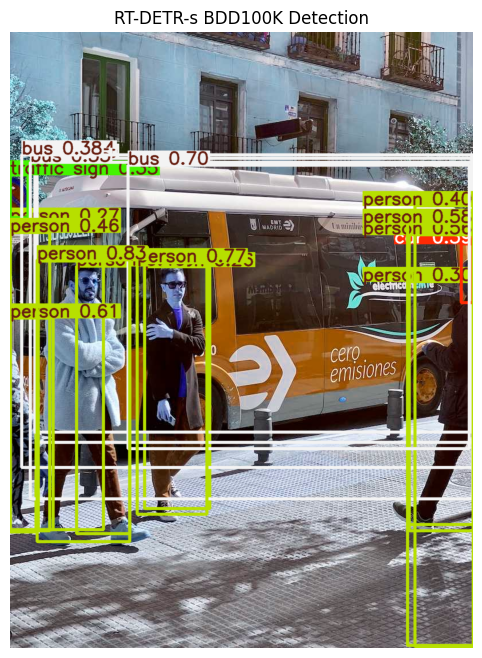

  person: 0.83
  person: 0.77
  bus: 0.70
  person: 0.61
  person: 0.58
  person: 0.56
  person: 0.46
  person: 0.42
  person: 0.40
  person: 0.40
  car: 0.39
  bus: 0.38
  bus: 0.35
  traffic sign: 0.35
  bus: 0.34
  person: 0.30
  bus: 0.30
  person: 0.27
  person: 0.26


In [ ]:
from ultralytics import RTDETR
from PIL import Image
import matplotlib.pyplot as plt

SAVE_PATH = '/content/drive/MyDrive/100-days-of-ml/capstone-autonomous-perception'

# Load best model
model = RTDETR(f'{SAVE_PATH}/rtdetr_s_bdd100k_training/weights/best.pt')

# Predict on a sample image (use any image URL or path)
results = model.predict(
    source='https://ultralytics.com/images/bus.jpg',  # Sample image
    conf=0.25,
    save=False
)

# Display
plt.figure(figsize=(12, 8))
plt.imshow(results[0].plot())
plt.axis('off')
plt.title('RT-DETR-s BDD100K Detection')
plt.show()

# Print detections
for box in results[0].boxes:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    cls_name = model.names[cls_id]
    print(f"  {cls_name}: {conf:.2f}")

In [ ]:
# Per-class AP
print("Per-class AP@50:")
print("-" * 30)

for i, ap in enumerate(metrics.box.ap50):
    class_name = class_names[i] if i < len(class_names) else f"class_{i}"
    print(f"  {class_name:15s}: {ap:.4f}")

Per-class AP@50:
------------------------------


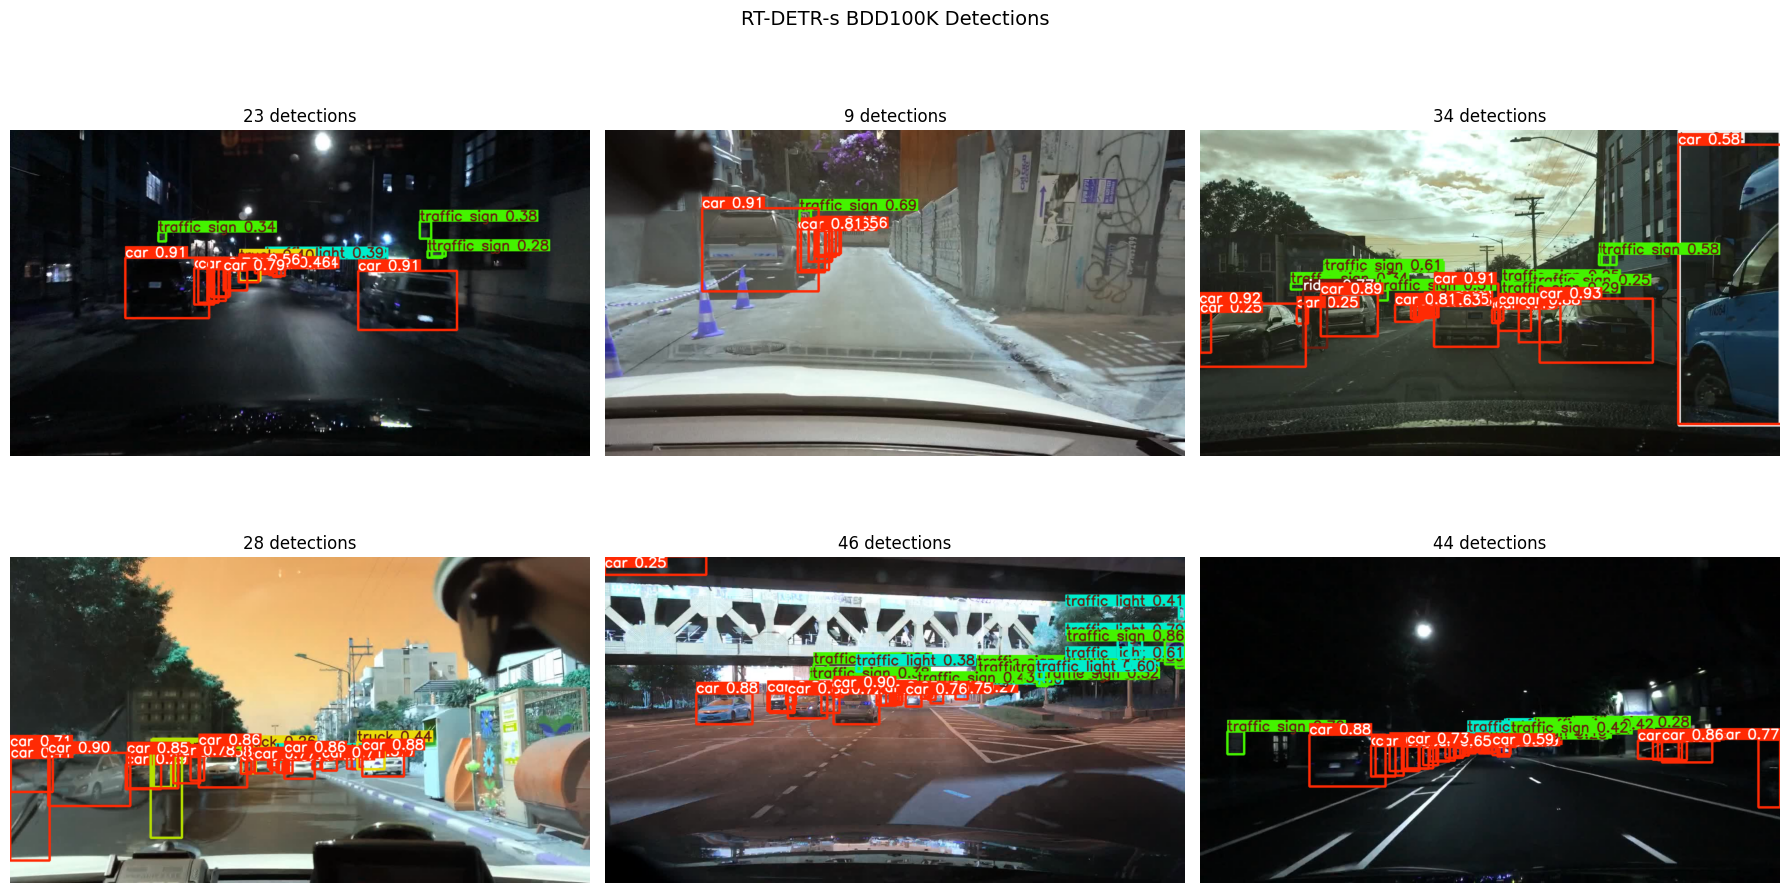

In [ ]:
# Predict on validation images
sample_val_images = np.random.choice(val_images, 6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, img_path in enumerate(sample_val_images):
    results = model.predict(img_path, verbose=False, conf=0.25)
    result_img = results[0].plot()

    axes[i].imshow(result_img)
    axes[i].set_title(f"{len(results[0].boxes)} detections")
    axes[i].axis('off')

plt.suptitle('RT-DETR-s BDD100K Detections', fontsize=14)
plt.tight_layout()
plt.show()

Image: c17752b1-1949c442.jpg
Detections: 75

Detected objects:
--------------------------------------------------
  car             | Conf: 0.94 | Box: (1011, 256, 1280, 495)
  car             | Conf: 0.85 | Box: (763, 334, 830, 384)
  traffic sign    | Conf: 0.81 | Box: (790, 193, 872, 216)
  car             | Conf: 0.79 | Box: (301, 366, 354, 396)
  car             | Conf: 0.78 | Box: (233, 370, 305, 404)
  traffic sign    | Conf: 0.69 | Box: (1068, 230, 1136, 258)
  traffic light   | Conf: 0.60 | Box: (751, 172, 771, 211)
  car             | Conf: 0.59 | Box: (387, 361, 419, 388)
  car             | Conf: 0.58 | Box: (357, 365, 392, 392)
  traffic light   | Conf: 0.58 | Box: (409, 212, 429, 242)
  car             | Conf: 0.57 | Box: (723, 341, 756, 376)
  car             | Conf: 0.56 | Box: (431, 362, 460, 384)
  car             | Conf: 0.56 | Box: (738, 340, 772, 377)
  traffic sign    | Conf: 0.56 | Box: (896, 266, 932, 282)
  car             | Conf: 0.55 | Box: (694, 349, 717, 37

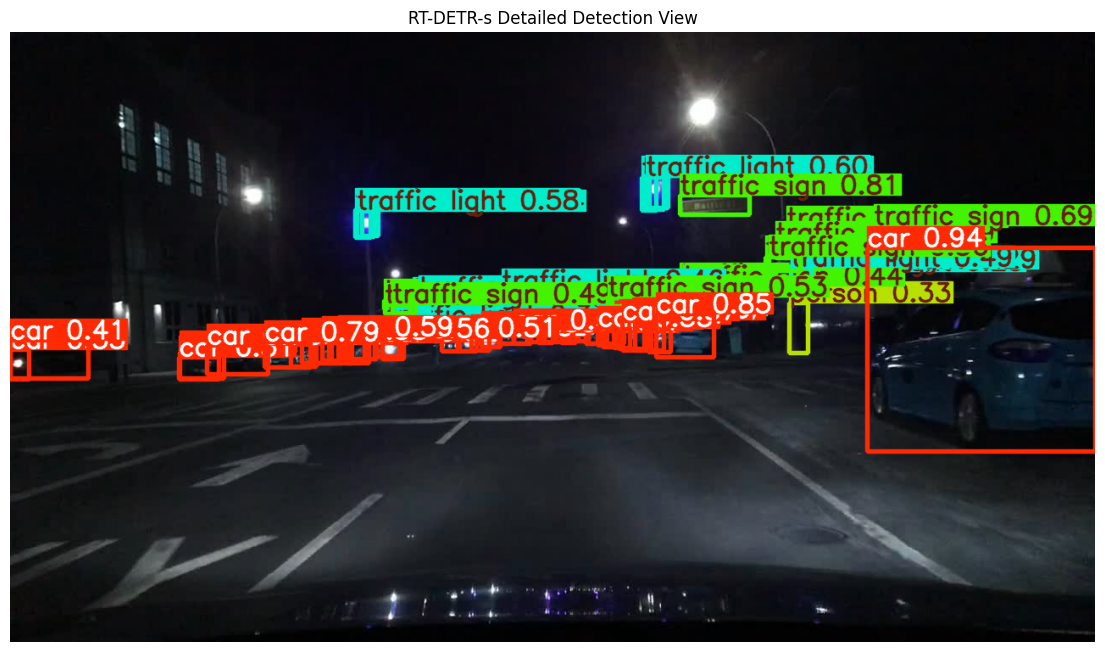

In [ ]:
import numpy as np

# Detailed view
class_names = CLASS_NAMES # Define class_names here
sample_img = val_images[np.random.randint(len(val_images))]
results = model.predict(sample_img, verbose=False, conf=0.25)

print(f"Image: {os.path.basename(sample_img)}")
print(f"Detections: {len(results[0].boxes)}")
print("\nDetected objects:")
print("-" * 50)

for box in results[0].boxes:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    class_name = class_names[cls_id] if cls_id < len(class_names) else f"class_{cls_id}"
    print(f"  {class_name:15s} | Conf: {conf:.2f} | Box: ({x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f})")

plt.figure(figsize=(14, 8))
plt.imshow(results[0].plot())
plt.axis('off')
plt.title('RT-DETR-s Detailed Detection View')
plt.show()

In [ ]:
# Benchmark
n_runs = 50
test_images = np.random.choice(val_images, n_runs, replace=True)

# Warmup
for _ in range(5):
    _ = model.predict(test_images[0], verbose=False)

times = []
for img_path in test_images:
    start = time.time()
    _ = model.predict(img_path, verbose=False)
    times.append(time.time() - start)

avg_time = np.mean(times) * 1000
fps = 1000 / avg_time

print(f"""
Inference Speed (PyTorch):
  Average: {avg_time:.1f} ms/image
  FPS: {fps:.1f}
  Min: {min(times)*1000:.1f} ms
  Max: {max(times)*1000:.1f} ms

Note: RT-DETR has NO NMS overhead (end-to-end)
""")


Inference Speed (PyTorch):
  Average: 45.1 ms/image
  FPS: 22.2
  Min: 43.6 ms
  Max: 49.4 ms

Note: RT-DETR has NO NMS overhead (end-to-end)



In [ ]:
IMG_SIZE = 640

In [ ]:
# Export to ONNX
print("Exporting to ONNX...")

onnx_path = model.export(
    format='onnx',
    imgsz=IMG_SIZE,
    simplify=True,
    dynamic=False
)

print(f"\nONNX model exported!")

Exporting to ONNX...
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
rt-detr-l summary: 313 layers, 32,004,290 parameters, 0 gradients, 103.5 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/100-days-of-ml/capstone-autonomous-perception/rtdetr_s_bdd100k_training/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 14) (188.5 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 187ms
Prepared 4 packages in 3.35s
Installed 4 packages in 320ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.25.0
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 4.4s
WARNING ⚠️ requirements: Restart runtime or rerun command f

Constant folding - Only steps=1 can be constant folded for opset >= 10 onnx::Slice op. Constant folding not applied. (Triggered internally at /pytorch/torch/csrc/jit/passes/onnx/constant_fold.cpp:178.)
Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
Constant folding - Only steps=1 can be constant folded for opset >= 10 onnx::Slice op. Constant folding not applied. (Triggered internally at /pytorch/torch/csrc/jit/passes/onnx/constant_fold.cpp:178.)
Constant folding - Only steps=1 can be constant folded for opset >= 10 onnx::Slice op. Constant folding not applied. (Triggered internally at /pytorch/torch/csrc/jit/passes/onnx/constant_fold.cpp:178.)


ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 21.8s, saved as '/content/drive/MyDrive/100-days-of-ml/capstone-autonomous-perception/rtdetr_s_bdd100k_training/weights/best.onnx' (125.4 MB)

Export complete (23.8s)
Results saved to /content/drive/MyDrive/100-days-of-ml/capstone-autonomous-perception/rtdetr_s_bdd100k_training/weights
Predict:         yolo predict task=detect model=/content/drive/MyDrive/100-days-of-ml/capstone-autonomous-perception/rtdetr_s_bdd100k_training/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/drive/MyDrive/100-days-of-ml/capstone-autonomous-perception/rtdetr_s_bdd100k_training/weights/best.onnx imgsz=640 data=/content/drive/MyDrive/100-days-of-ml/capstone-autonomous-perception/data.yaml  
Visualize:       https://netron.app

ONNX model exported!


In [ ]:
# Check ONNX file
if os.path.exists(onnx_path):
    onnx_size = os.path.getsize(onnx_path) / (1024 * 1024)
    print(f"ONNX file: {onnx_path}")
    print(f"Size: {onnx_size:.1f} MB")

    import shutil
    shutil.copy(onnx_path, f"{SAVE_PATH}/rtdetr_s_bdd100k.onnx")
    print(f"\nCopied to: {SAVE_PATH}/rtdetr_s_bdd100k.onnx")

ONNX file: /content/drive/MyDrive/100-days-of-ml/capstone-autonomous-perception/rtdetr_s_bdd100k_training/weights/best.onnx
Size: 125.4 MB

Copied to: /content/drive/MyDrive/100-days-of-ml/capstone-autonomous-perception/rtdetr_s_bdd100k.onnx


In [ ]:
# Save artifacts for Day 61 & 62
import json

FINETUNED_MODEL_PATH = f"{SAVE_PATH}/rtdetr_s_bdd100k_training/weights/best.pt"
data_yaml_path = f"{SAVE_PATH}/data.yaml"

artifacts = {
    'model_type': 'RT-DETR-s',
    'class_names': class_names,
    'num_classes': len(class_names),
    'img_size': IMG_SIZE,
    'model_path': FINETUNED_MODEL_PATH,
    'onnx_path': f"{SAVE_PATH}/rtdetr_s_bdd100k.onnx",
    'dataset_path': data_yaml_path,
    'metrics': {
        'mAP50': float(metrics.box.map50),
        'mAP50_95': float(metrics.box.map),
        'precision': float(metrics.box.mp),
        'recall': float(metrics.box.mr)
    }
}

with open(f"{SAVE_PATH}/day60_artifacts.json", 'w') as f:
    json.dump(artifacts, f, indent=2)

print("Artifacts saved!")
print(f"\nSaved to: {SAVE_PATH}/day60_artifacts.json")

Artifacts saved!

Saved to: /content/drive/MyDrive/100-days-of-ml/capstone-autonomous-perception/day60_artifacts.json


In [ ]:
!ls -la /content/drive/MyDrive/100-days-of-ml/capstone-autonomous-perception/rtdetr_s_bdd100k_training/weights/

total 514492
-rw------- 1 root root 131537676 Apr 25 14:01 best.onnx
-rw------- 1 root root 197649625 Apr 25 04:12 best.pt
-rw------- 1 root root 197651417 Apr 25 13:16 last.pt


In [ ]:
from google.colab import files

files.download('/content/drive/MyDrive/100-days-of-ml/capstone-autonomous-perception/rtdetr_s_bdd100k_training/weights/best.onnx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>